In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import MaxNLocator

In [2]:
def orig_func(x):
    x0,x1=x[0],x[1]
    return (1-x0)**2+100*(x1-x0**2)**2

In [3]:
def nonlin_func(x):
    x0,x1=x[0],x[1]
    return np.array([
        -2*(1-x0)-400*x0*(x1-x0**2),
        200*(x1-x0**2)
    ])

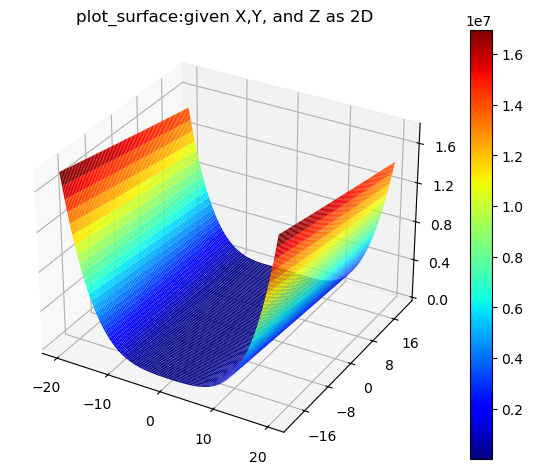

In [5]:
#graphing orig_func
x=np.linspace(-20,20,100)
y=np.linspace(-20,20,100)
X,Y=np.meshgrid(x,y)

Z=orig_func(np.array([X,Y]))

fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')

surf=ax.plot_surface(X,Y,Z,rstride=1,cstride=1,cmap=cm.jet,linewidth=0)
fig.colorbar(surf)

title=ax.set_title("plot_surface:given X,Y, and Z as 2D")
title.set_y(1.01)

ax.xaxis.set_major_locator(MaxNLocator(5))
ax.yaxis.set_major_locator(MaxNLocator(6))
ax.zaxis.set_major_locator(MaxNLocator(5))

fig.tight_layout()

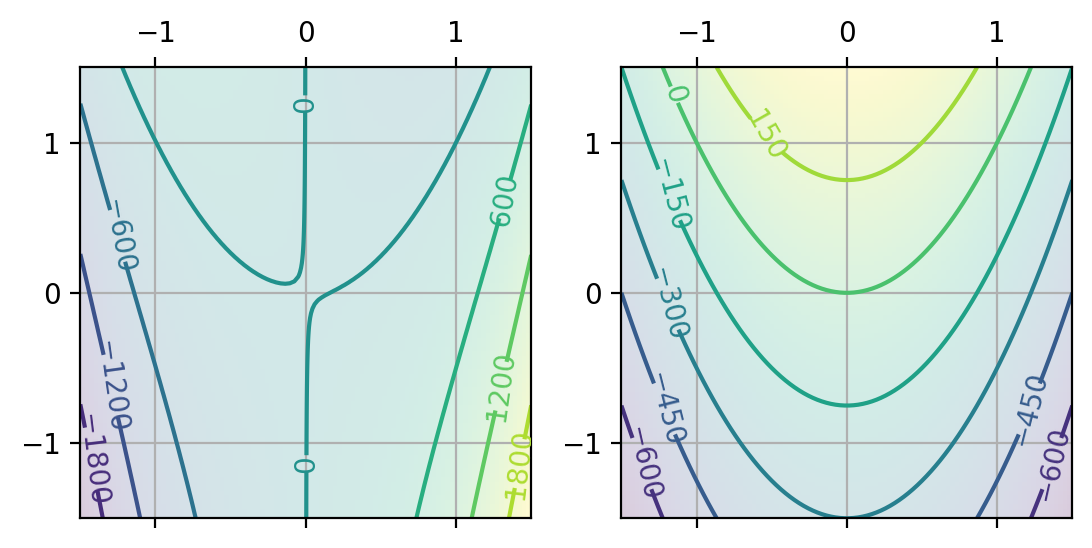

In [6]:
#graphing nonlin_func (gradient of orig_func)
x=np.linspace(-1.5,1.5,100)
y=np.linspace(-1.5,1.5,100)
X,Y=np.meshgrid(x,y)
output=nonlin_func(np.array([X,Y]))

fig,axs=plt.subplots(1,2,dpi=200)

my_extent=[min(x),max(x),min(y),max(y)]
axs[0].matshow(output[0],origin="lower",extent=my_extent,alpha=0.2)
csx=axs[0].contour(X,Y,output[0])
axs[0].clabel(csx)

axs[1].matshow(output[1],origin="lower",extent=my_extent,alpha=0.2)
csy=axs[1].contour(X,Y,output[1])
axs[1].clabel(csy)

for ax in axs:
    ax.grid(True)

In [7]:
def jacobian(vec_fld,x,h=1e-6):
    n=x.size
    Jf=np.zeros((n,n))
    iden=np.eye(n)
    fs0=vec_fld(x)
    for j in range(n):
        fs1=vec_fld(x+iden[:,j]*h)
        Jf[:,j]=(fs1-fs0)/h
 
    return Jf,fs0

In [8]:
def termcrit(xolds,xnews):
    errs = np.abs((xnews - xolds)/xnews)
    return np.sum(errs)

In [9]:
def multi_newton(input_func, jac, xolds, kmax=500,tol=1.e-8):
    
    for k in range(1, kmax):
        Jf, fs_xolds = jacobian(input_func, xolds)
        xnews = xolds + np.linalg.solve(Jf, -fs_xolds)

        err=termcrit(xolds,xnews)
        print(k,xnews,err)
        if err<tol:
            break

        xolds = np.copy(xnews)
    else:
        xnews=None
    return xnews

root = multi_newton(nonlin_func, jacobian, np.array([1., 1.]))
print(f"Root found at {root}")
print(f"f(root) is {nonlin_func(root)})")

1 [1. 1.] 0.0
Root found at [1. 1.]
f(root) is [-0.  0.])


1 [-0.99501246  0.99002493] 2.0150881082354504
2 [ 0.99091218 -2.96198776] 3.338381311664893
3 [0.99092369 0.98192975] 4.016508206977156
4 [0.9999964 0.9999105] 0.02705509928484704
5 [0.99999994 0.99999988] 9.292195289353663e-05
6 [1. 1.] 1.7894924176520657e-07
7 [1. 1.] 7.149170144771347e-11
Root found at [1. 1.] => L2 = 1.9095836023552692e-14
1 [ 1.00080032 -3.00159864] 3.332356121951228
2 [1.00079932 1.00159928] 3.996806897597909
3 [1.00000032 1.        ] 0.0023982832982674916
4 [1. 1.] 3.196744910465447e-07
5 [1. 1.] 5.053546470178959e-10
Root found at [1. 1.] => L2 = 2.281840818028513e-13
1 [1. 1.] 2.000000000066393
2 [1. 1.] 6.639311322942376e-11
Root found at [1. 1.] => L2 = 0.0
1 [1.e+00 1.e-06] 2.0
2 [1. 1.] 0.9999990000320025
3 [1. 1.] 8.812666152381859e-10
Root found at [1. 1.] => L2 = 4.1354941833285496e-13
1 [1. 1.] 0.0
Root found at [1. 1.] => L2 = 0.0
1 [-0.99501246  0.99002493] 2.0150881082354504
2 [ 0.99091218 -2.96198776] 3.338381311664893
3 [0.99092369 0.98192975] 4.

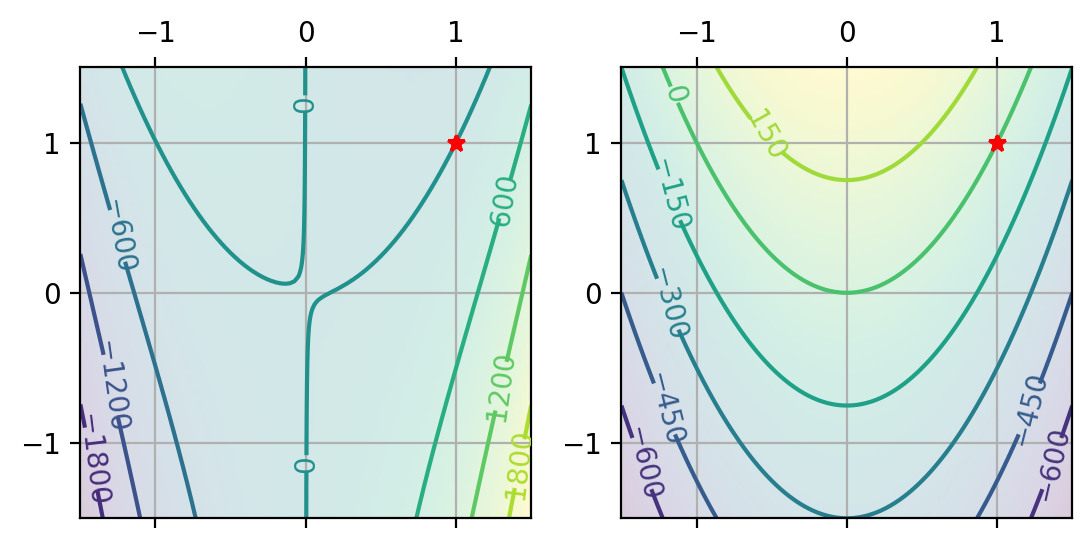

In [10]:
x = np.linspace(-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x, y)
output = nonlin_func(np.array([X, Y]))

fig, axs = plt.subplots(1, 2, dpi=200)
my_extent = [min(x), max(x), min(y), max(y)]
axs[0].matshow(output[0], origin="lower", extent=my_extent, alpha=0.2)
csx = axs[0].contour(X, Y, output[0])
axs[0].clabel(csx)

axs[1].matshow(output[1], origin="lower", extent=my_extent, alpha=0.2)
csy = axs[1].contour(X, Y, output[1])
axs[1].clabel(csy)

for ax in axs:
    ax.grid(True)
    ## Try out different x0 and see where they will land
    for x0 in [[-1, -1],[-1, 1], [1, -1], [0,0], [1,1]]:
        root = multi_newton(nonlin_func, jacobian, np.array(x0))
        print(f"Root found at {root} => L2 = {np.linalg.norm(nonlin_func(root))}")
        ax.plot(root[0], root[1], "r*")